# nb05 — RNA concordance across independent captures

## Scientific question
For one donor, do CITE-seq and Multiome recover the same cell-type-specific genes
and biological pathways, sufficiently consistently to motivate multimodal follow-up?

## Analysis strategy
Compare independent cell-type mean profiles on one shared gene universe, inspect
specificity-rank and top-gene agreement, and compare pathway NES with statistical
support. Repeat expression comparisons with equal cell counts and inspect shared
sites. Shortlist replicated positive programs by effect, shared leading edge and
cell-type diversity. Explore a shared uncorrected PCA of population means only.

Run nb04 first. This notebook reads its saved outputs and verifies hashes to reject
mixed/stale runs. It never aligns CITE and Multiome cells by row or barcode.

In [1]:
from pathlib import Path
import sys
import subprocess

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Same Drive root as nb01. No changes to the original benchmark files.
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'anndata>=0.11,<0.13'])
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/multiomics-relationship-modeling')
else:
    BASE_PATH = Path.cwd().resolve()
    if not (BASE_PATH / 'src').is_dir():
        BASE_PATH = BASE_PATH.parent

if not (BASE_PATH / 'src/single_donor_workflow.py').is_file():
    raise FileNotFoundError('Copy the updated src/, configs/ and new notebooks to the project on Drive first.')
sys.path.insert(0, str(BASE_PATH))
import pandas as pd
from IPython.display import display, Image
from configs.paths import CITE_H5AD, MULTIOME_H5AD
from src.single_donor_io import output_dirs

OUTPUT_ROOT = BASE_PATH / 'results/single_donor'
DIRS = output_dirs(OUTPUT_ROOT)
print('Colab:', IN_COLAB, '| Project:', BASE_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Colab: True | Project: /content/drive/MyDrive/multiomics-relationship-modeling


In [2]:
from src.single_donor_workflow import load_characterization, run_concordance
manifest, programs, enrichment, universe, rna_data = load_characterization(OUTPUT_ROOT)
display(manifest)
print('Donor:', manifest['donor'], '| Shared genes:', len(universe))

{'donor': '15078',
 'min_cells': 50,
 'min_shared': 3,
 'max_dominance': 0.7,
 'retained_cell_types': ['CD14 monocytes',
  'CD4 T cells',
  'Erythroid populations',
  'B cells',
  'CD8 T cells',
  'NK cells',
  'CD16 monocytes',
  'pDC',
  'cDC2',
  'G/M progenitors',
  'HSC',
  'Lymphoid progenitors',
  'Plasma cells',
  'MK/E progenitors',
  'ILC'],
 'inputs': {'cite': {'path': '/content/drive/MyDrive/multiomics-relationship-modeling/data/benchmark/GSE194122_openproblems_neurips2021_cite_BMMC_processed.h5ad',
   'file_bytes': 624797386,
   'file_mtime_ns': 1782768387000000000,
   'shape': [90261, 14087],
   'feature_types': {'GEX': 13953, 'ADT': 134},
   'repeated_feature_names': [{'name': 'CD52',
     'feature_types': ['GEX', 'ADT']},
    {'name': 'CD58', 'feature_types': ['GEX', 'ADT']},
    {'name': 'CD2', 'feature_types': ['GEX', 'ADT']},
    {'name': 'CD101', 'feature_types': ['GEX', 'ADT']},
    {'name': 'CD48', 'feature_types': ['GEX', 'ADT']},
    {'name': 'CD244', 'feature_t

Donor: 15078 | Shared genes: 12000


## Expression, ranked-gene and pathway concordance
Pearson/Spearman correlations use independent within-cell-type average RNA profiles.
Specificity-rank Spearman is computed over the complete shared eligible gene list.
Top-50/100/250 overlap uses only positive-specificity genes, with actual list lengths
reported when fewer genes qualify. No gene-correlation p-values are interpreted as
evidence across individuals.

Pathway classes use q ≤ 0.05 in both captures for concordant active/negative or
opposite-direction discordant results. A pathway significant in only one capture is
labelled capture-specific **descriptively**; a difference in significance does not
establish a significant difference. Non-significant results are unsupported, never
automatically inactive. Negative enrichment denotes relative underrepresentation.

Five balanced sampling repeats use independent draws in each capture and the same
cell count per cell type (minimum of both available counts and 1000). This is a
sensitivity analysis, not five biological replicates. One balanced draw also repeats
enrichment with the original shared gene universe and collection. Site-specific
comparisons require at least two adequately represented shared cell types.

,cell_type,n_genes,n_cite,n_multiome,pearson,spearman,specificity_rank_spearman
0,B cells,12000,3449,2798,0.610950,0.727238,0.628569
1,CD14 monocytes,12000,7244,3243,0.494087,0.740322,0.734600
2,CD16 monocytes,12000,865,526,0.609105,0.778698,0.745427
3,CD4 T cells,12000,5619,3099,0.690891,0.768995,0.652523
4,CD8 T cells,12000,2545,1653,0.692064,0.773926,0.633667
5,Erythroid populations,12000,5067,2851,0.737422,0.821538,0.586699
6,G/M progenitors,12000,517,341,0.504290,0.624061,0.393287
7,HSC,12000,455,230,0.611278,0.617951,0.589191
8,ILC,12000,151,120,0.839406,0.729760,0.152046
9,Lymphoid progenitors,12000,449,452,0.590282,0.663193,0.529439


,cell_type,top_n,n_cite,n_multiome,intersection,union,jaccard,overlapping_genes
0,B cells,50,50,50,13,87,0.149425,AFF3;BANK1;CD74;CD79B;FCRL1;HLA-DQA1;HLA-DRA;H...
1,B cells,100,100,100,29,171,0.169591,AFF3;BANK1;BIRC3;BLK;CD22;CD37;CD69;CD74;CD79B...
2,B cells,250,250,250,91,409,0.222494,AFF3;AL139020.1;ARHGAP24;ARID5B;BACH2;BANK1;BC...
3,CD14 monocytes,50,50,50,7,93,0.075269,ANXA1;CD36;FCN1;NAMPT;NEAT1;SAT1;VCAN
4,CD14 monocytes,100,100,100,22,178,0.123596,ANXA1;CD36;CD44;CLEC12A;CSF3R;CYBB;FCN1;FOS;FO...
5,CD14 monocytes,250,250,250,79,421,0.187648,AC020916.1;AHNAK;AKAP13;ANXA1;AOAH;APLP2;ASAH1...
6,CD16 monocytes,50,50,50,11,89,0.123596,COTL1;CTSS;FCGR3A;FTH1;MS4A7;NEAT1;POU2F2;PSAP...
7,CD16 monocytes,100,100,100,37,163,0.226994,AIF1;ASAH1;C5AR1;CLEC12A;COTL1;CSF1R;CST3;CTSS...
8,CD16 monocytes,250,250,250,100,400,0.250000,ACTR2;ADGRE2;ADGRE5;AHNAK;AIF1;ASAH1;C5AR1;CDK...
9,CD4 T cells,50,50,50,7,93,0.075269,BCL11B;CD2;IL32;IL7R;LTB;TMSB4X;TRAC


,cell_type,pathway,NES_cite,NES_multiome,q_value_cite,q_value_multiome,concordance
0,B cells,Adipogenesis,-1.583890,-1.204486,0.009452,0.214019,CITE-specific
1,B cells,Allograft Rejection,1.457552,-0.983466,0.074561,0.579952,unsupported
2,B cells,Androgen Response,-1.052746,-1.399342,0.422859,0.057310,unsupported
3,B cells,Angiogenesis,-1.647679,-1.252268,0.019231,0.271703,CITE-specific
4,B cells,Apical Junction,-1.550492,-1.244534,0.019231,0.205610,CITE-specific
...,...,...,...,...,...,...,...
730,pDC,Wnt-beta Catenin Signaling,-1.329584,-1.091718,0.423077,0.632917,unsupported
731,pDC,Xenobiotic Metabolism,1.307202,1.180531,0.344659,0.448663,unsupported
732,pDC,heme Metabolism,-1.571562,-1.909080,0.344659,0.272222,unsupported
733,pDC,mTORC1 Signaling,1.099384,1.133127,0.631636,0.476793,unsupported


,cell_type,n_pathways,pearson,spearman
0,B cells,49,0.555172,0.559388
1,CD14 monocytes,49,0.942901,0.794490
2,CD16 monocytes,49,0.911827,0.892143
3,CD4 T cells,49,0.602154,0.705510
4,CD8 T cells,49,0.600781,0.663367
5,Erythroid populations,49,0.680426,0.700612
6,G/M progenitors,49,0.409107,0.401842
7,HSC,49,0.678238,0.702959
8,ILC,49,0.069514,0.152959
9,Lymphoid progenitors,49,0.602154,0.722551


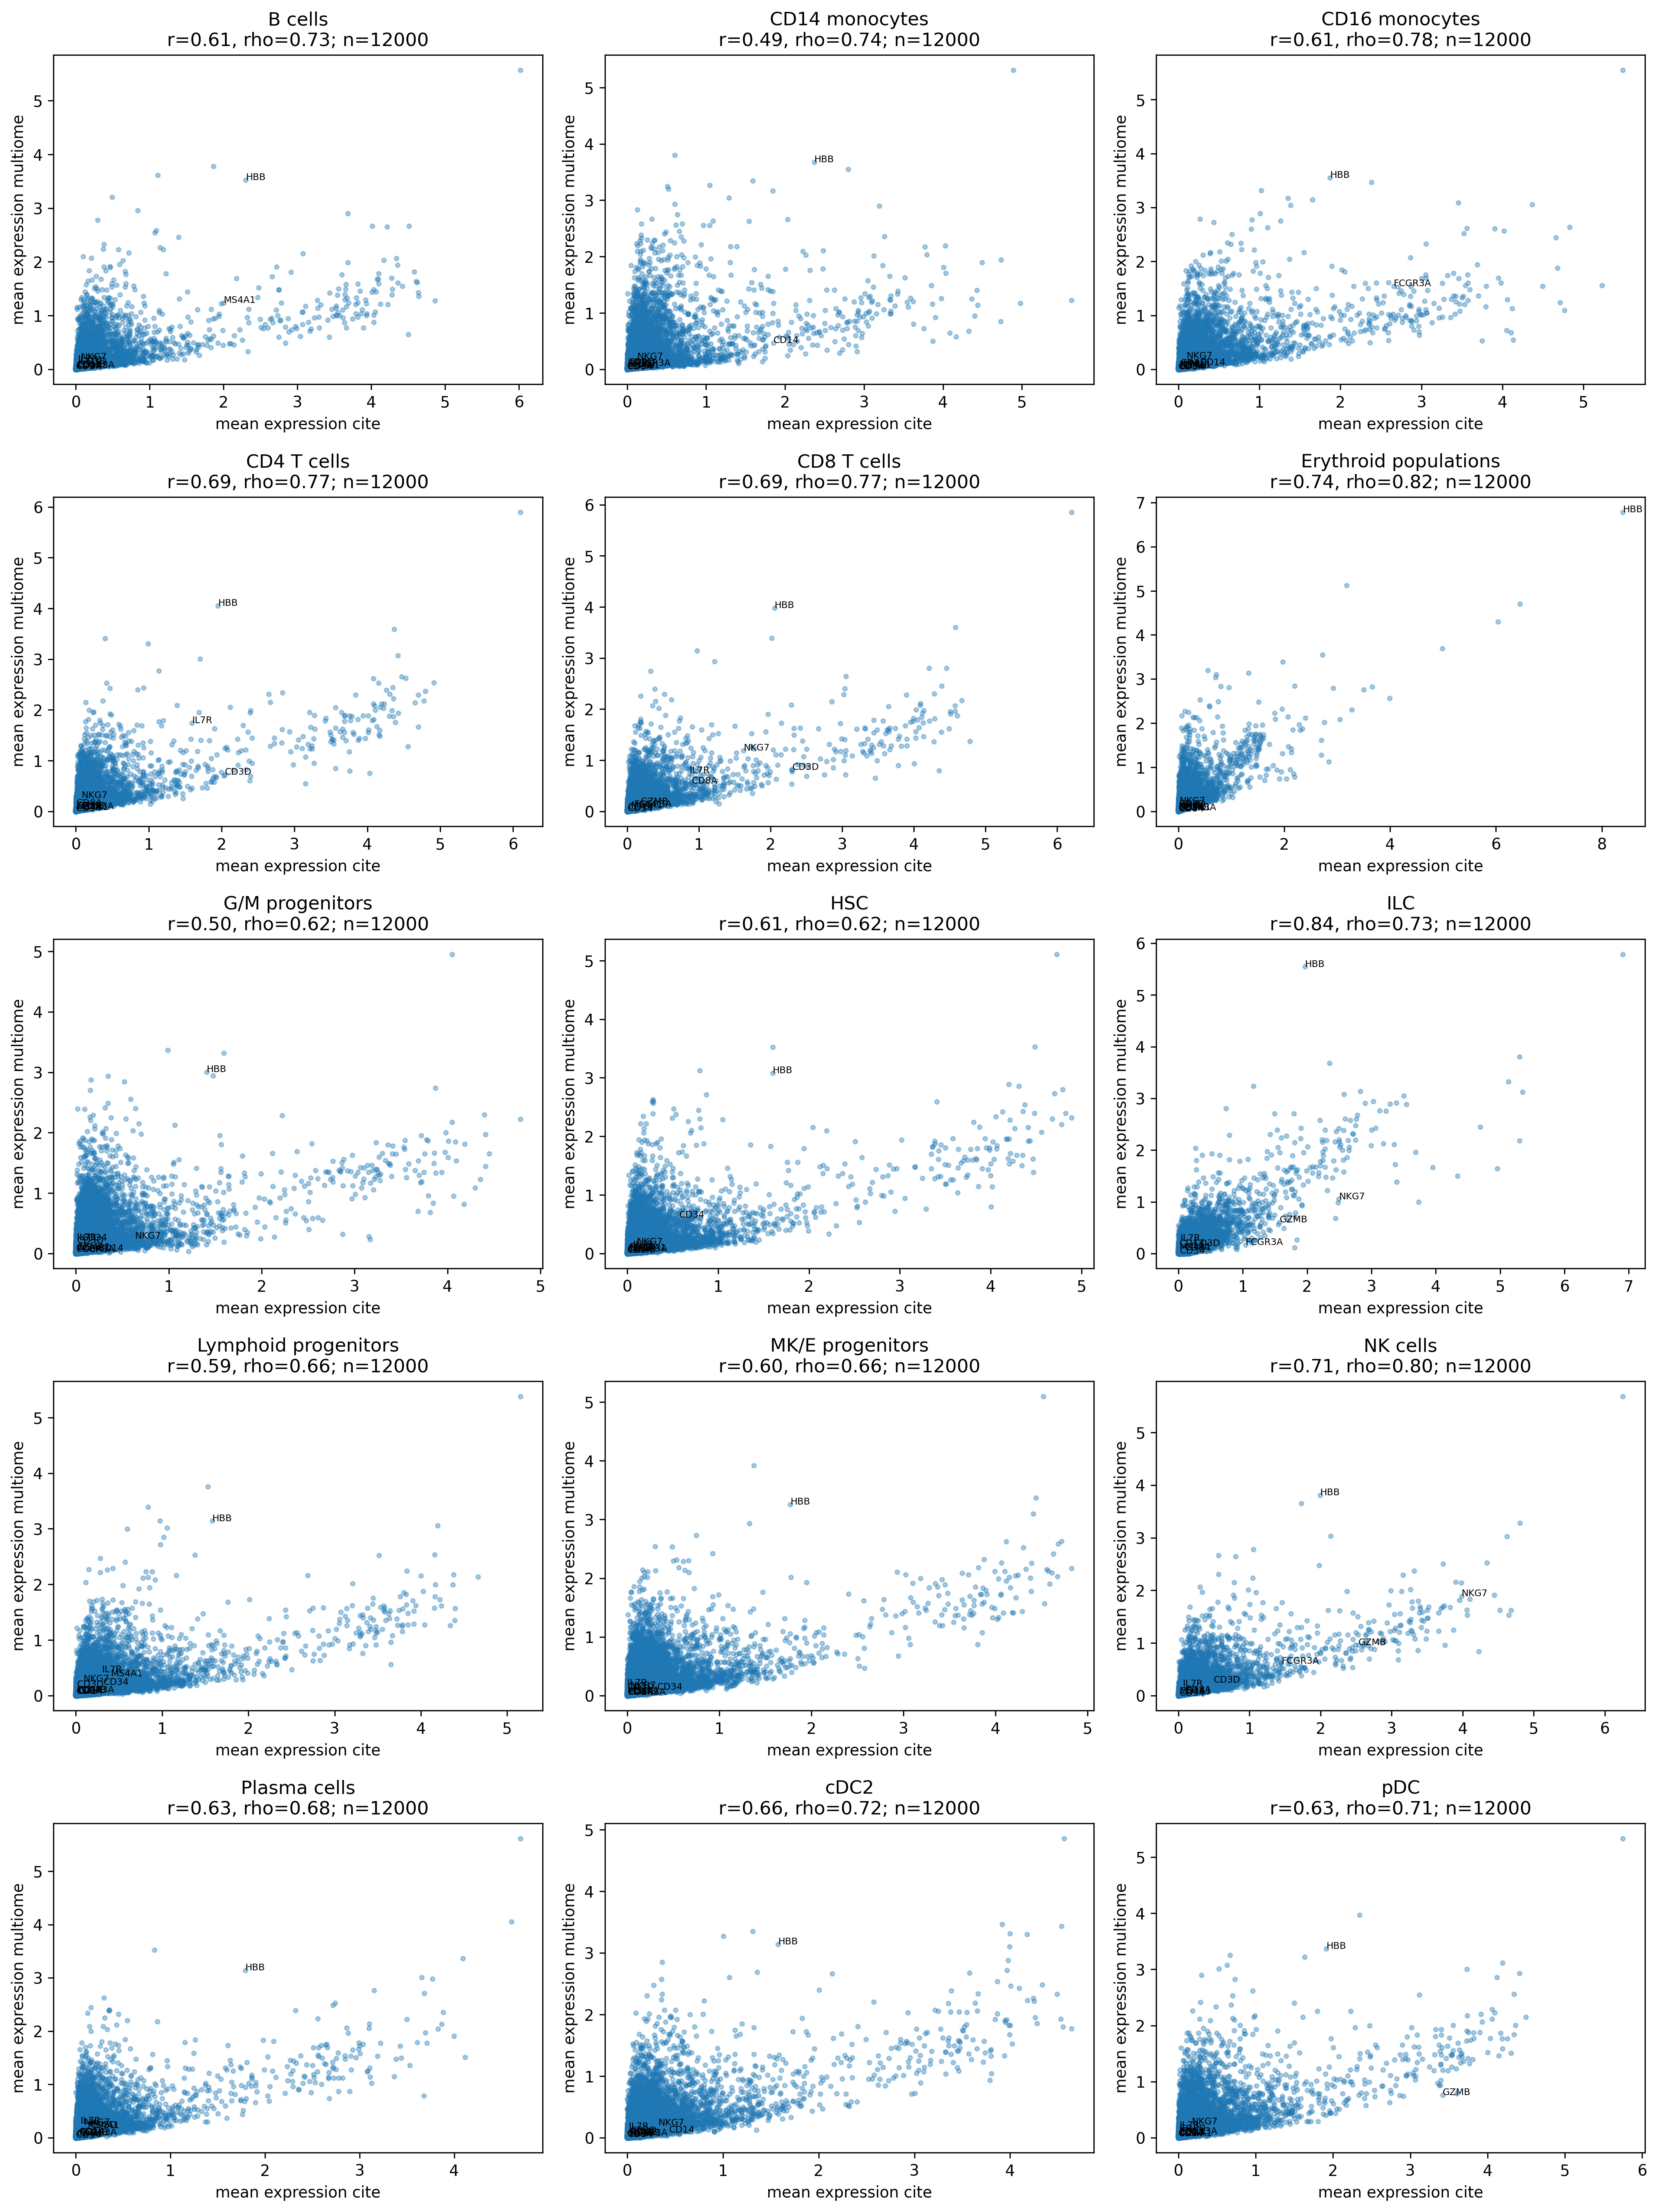

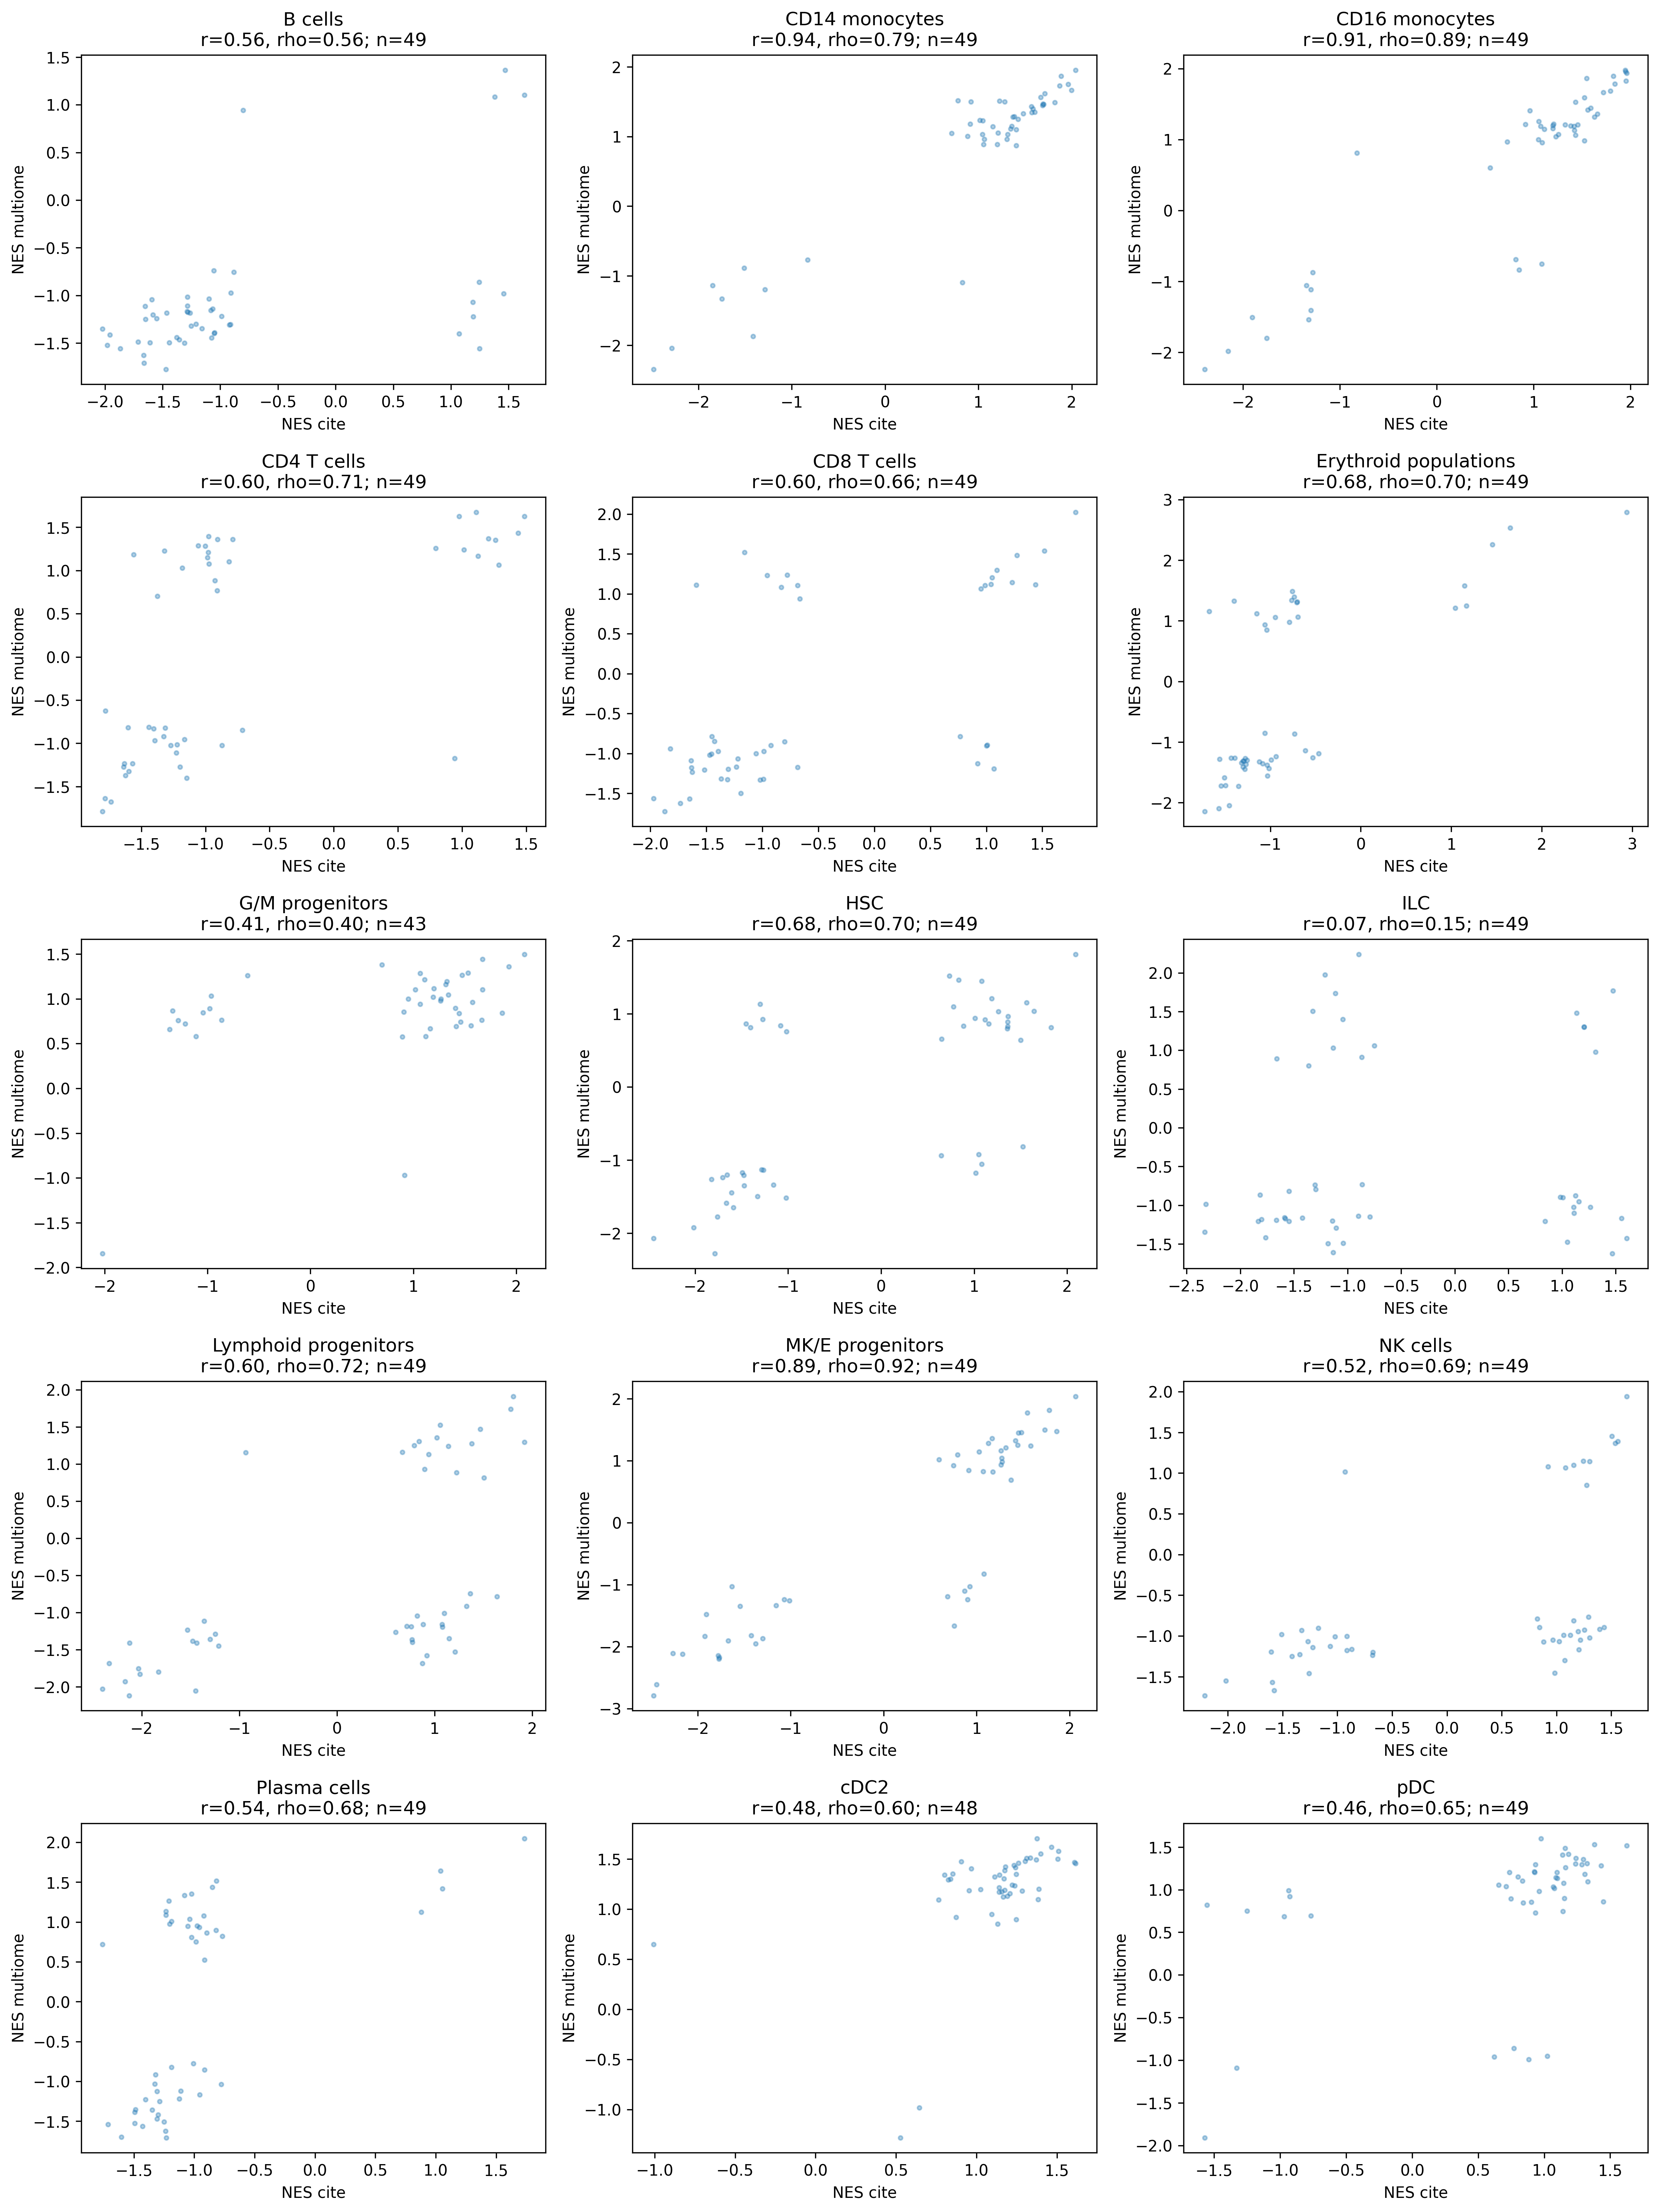

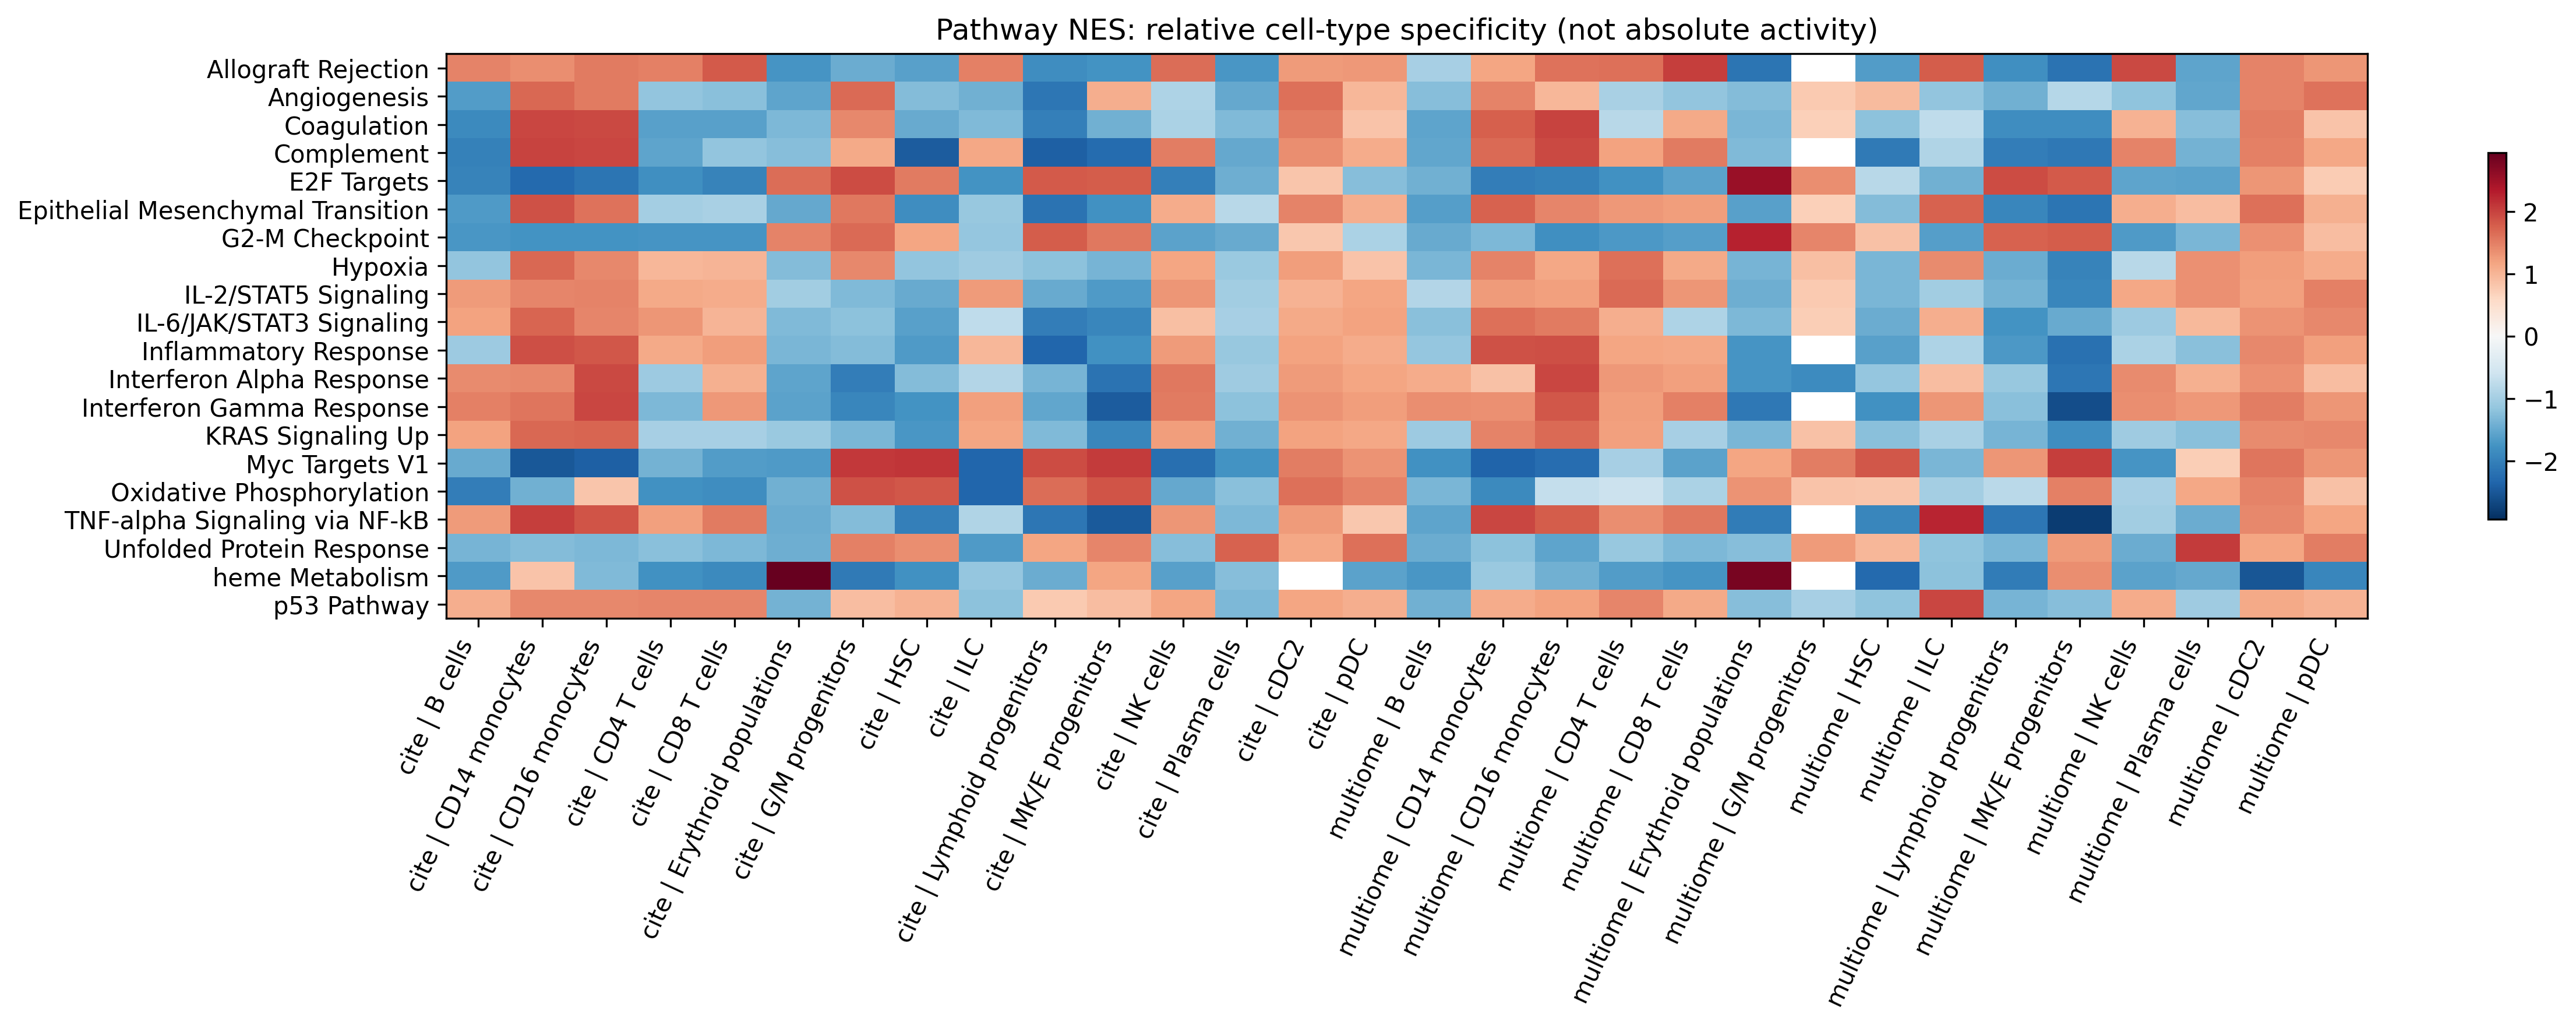

In [3]:
BALANCED_REPEATS = 5
BALANCED_CAP = 1000
expression_comparison, pathway_comparison, followup, findings = run_concordance(
    OUTPUT_ROOT, repeats=BALANCED_REPEATS, cap=BALANCED_CAP)
display(expression_comparison)
display(pd.read_csv(DIRS['rna_concordance'] / 'top_gene_overlap.csv'))
display(pathway_comparison[['cell_type', 'pathway', 'NES_cite', 'NES_multiome', 'q_value_cite', 'q_value_multiome', 'concordance']])
display(pd.read_csv(DIRS['rna_concordance'] / 'pathway_correlations.csv'))
for name in ['expression_scatter', 'pathway_nes_scatter', 'pathway_concordance_heatmap']:
    figure = DIRS['rna_concordance'] / 'figures' / f'{name}.png'
    if figure.exists() and (name == 'expression_scatter' or not pathway_comparison.empty):
        display(Image(filename=str(figure)))

## Unequal cell numbers and donor/site composition
Compare the balanced ranges below to the complete-profile estimates above. A range
across draws describes sampling sensitivity, not confidence across donors. Shared
site analyses change the comparator pool when some populations are absent; inspect
their coverage table. If no shared site is testable, site confounding remains
unresolved. With one selected donor, donor effects cannot be estimated.

In [4]:
sensitivity = pd.read_csv(DIRS['rna_concordance'] / 'balanced_expression_sensitivity.csv')
display(sensitivity.groupby('cell_type')[['pearson', 'spearman', 'specificity_rank_spearman']].agg(['min', 'median', 'max']))
display(pd.read_csv(DIRS['rna_concordance'] / 'balanced_pathway_sensitivity.csv'))
display(pd.read_csv(DIRS['rna_concordance'] / 'site_sensitivity_coverage.csv'))
display(pd.read_csv(DIRS['rna_concordance'] / 'site_expression_sensitivity.csv'))

pearson                      spearman            \
                            min    median       max       min    median   
cell_type                                                                 
B cells                0.605212  0.609533  0.613807  0.715030  0.716177   
CD14 monocytes         0.492637  0.495434  0.508217  0.730572  0.732177   
CD16 monocytes         0.606543  0.607289  0.610889  0.772962  0.773907   
CD4 T cells            0.686154  0.689401  0.693112  0.755705  0.759383   
CD8 T cells            0.687608  0.688932  0.693399  0.763995  0.766145   
Erythroid populations  0.730901  0.734666  0.742079  0.806569  0.812343   
G/M progenitors        0.502901  0.504741  0.507458  0.617352  0.620889   
HSC                    0.609585  0.611096  0.615044  0.610613  0.612788   
ILC                    0.836265  0.837050  0.838997  0.718691  0.720171   
Lymphoid progenitors   0.589314  0.589756  0.591374  0.662582  0.662961   
MK/E progenitors       0.595270  0.598273  0.600757  0.647632  0.651533   
NK cells               0.706109  0.715698  0.716176  0.793773  0.798503   
Plasma cells           0.626024  0.628619  0.629554  0.681442  0.682305   
cDC2                   0.654133  0.657414  0.658200  0.709896  0.713312   
pDC                    0.627646  0.627855  0.631747  0.706814  0.707892   

                                specificity_rank_spearman                      
                            max                       min    median       max  
cell_type                                                                      
B cells                0.721706                  0.583783  0.588225  0.605391  
CD14 monocytes         0.738218                  0.708192  0.710578  0.711269  
CD16 monocytes         0.775875                  0.729360  0.729632  0.733250  
CD4 T cells            0.760232                  0.593502  0.618276  0.634061  
CD8 T cells            0.766620                  0.597676  0.611540  0.615292  
Erythroid populations  0.818608                  0.555602  0.578876  0.595707  
G/M progenitors        0.621772                  0.374013  0.377930  0.393810  
HSC                    0.619649                  0.560381  0.570032  0.577396  
ILC                    0.723369                  0.146898  0.152155  0.154509  
Lymphoid progenitors   0.663534                  0.519953  0.527219  0.532809  
MK/E progenitors       0.656469                  0.649299  0.652692  0.666106  
NK cells               0.800743                  0.589153  0.602470  0.618726  
Plasma cells           0.683713                  0.460895  0.473292  0.483212  
cDC2                   0.715644                  0.594738  0.600754  0.616598  
pDC                    0.711349                  0.625965  0.633902  0.642493

,pathway,ES_cite,NES_cite,p_value_cite,direction_cite,leading_edge_cite,n_genes_cite,n_original_genes_cite,coverage_cite,permutations_cite,...,n_genes_multiome,n_original_genes_multiome,coverage_multiome,permutations_multiome,n_null_same_sign_multiome,tied_fraction_multiome,q_value_multiome,n_cells_multiome,concordance,classification_note
0,Adipogenesis,-0.550792,-1.621057,0.001761,negative,AIFM1;FAH;ACLY;RREB1;APLP2;HADH;GRPEL1;CD151;M...,166,200,0.830000,1000,...,166,200,0.830000,1000,901,0.0,0.129342,1000,CITE-specific,Relative specificity; negative is not inactivi...
1,Allograft Rejection,0.499377,1.461294,0.027397,positive,HLA-DRA;LTB;CD74;HLA-DQA1;HLA-DMB;RPL39;HLA-DM...,158,200,0.790000,1000,...,158,200,0.790000,1000,897,0.0,0.625687,1000,unsupported,Relative specificity; negative is not inactivi...
2,Androgen Response,-0.399238,-1.066892,0.345238,negative,MAP7;ZMIZ1;INPP4B;CAMKK2;MAF;RPS6KA3;NDRG1;FAD...,82,100,0.820000,1000,...,82,100,0.820000,1000,853,0.0,0.129342,1000,unsupported,Relative specificity; negative is not inactivi...
3,Angiogenesis,-0.834576,-1.667423,0.004580,negative,CCND2;VCAN;TIMP1;S100A4,15,36,0.416667,1000,...,15,36,0.416667,1000,794,0.0,0.269209,1000,CITE-specific,Relative specificity; negative is not inactivi...
4,Apical Junction,-0.545222,-1.538628,0.005137,negative,FSCN1;HADH;SIRPA;ARHGEF6;ICAM2;TSPAN4;RSU1;MAP...,111,200,0.555000,1000,...,111,200,0.555000,1000,876,0.0,0.180510,1000,CITE-specific,Relative specificity; negative is not inactivi...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
730,Wnt-beta Catenin Signaling,-0.545418,-1.411161,0.069307,negative,FRAT1;AXIN1;CTNNB1;CUL1;TCF7;LEF1;RBPJ;MYC;CCND2,28,42,0.666667,1000,...,28,42,0.666667,1000,191,0.0,0.667468,338,unsupported,Relative specificity; negative is not inactivi...
731,Xenobiotic Metabolism,0.575136,1.297172,0.068182,positive,IRF8;DHRS7;SSR3;PTGDS;NMT1;TMBIM6;DDAH2;NPC1;P...,118,200,0.590000,1000,...,118,200,0.590000,1000,970,0.0,0.411277,338,unsupported,Relative specificity; negative is not inactivi...
732,heme Metabolism,-0.448657,-1.549707,0.045455,negative,MARK3;ELL2;FECH;RHCE;GCLM;HBQ1;MINPP1;FOXO3;BM...,180,200,0.900000,1000,...,180,200,0.900000,1000,14,0.0,0.272222,338,unsupported,Relative specificity; negative is not inactivi...
733,mTORC1 Signaling,0.478103,1.102465,0.295775,positive,HSP90B1;CTSC;DDIT4;PPP1R15A;SERP1;LGMN;CANX;PP...,189,200,0.945000,1000,...,189,200,0.945000,1000,994,0.0,0.480737,338,unsupported,Relative specificity; negative is not inactivi...


,Site,n_supported_types,tested
0,site1,8,True
1,site2,12,True
2,site4,11,True


,cell_type,n_genes,n_cite,n_multiome,pearson,spearman,specificity_rank_spearman,Site
0,B cells,12000,945,670,0.765870,0.779011,0.662907,site1
1,CD14 monocytes,12000,734,921,0.650190,0.780813,0.664788,site1
2,CD4 T cells,12000,1096,1379,0.784370,0.802198,0.710890,site1
3,CD8 T cells,12000,555,725,0.814887,0.818527,0.654645,site1
4,Erythroid populations,12000,1199,1249,0.782440,0.879162,0.651611,site1
5,Lymphoid progenitors,12000,67,52,0.806444,0.735860,0.616687,site1
6,NK cells,12000,213,591,0.863583,0.857857,0.521302,site1
7,pDC,12000,57,92,0.784343,0.757947,0.662193,site1
8,B cells,12000,1157,387,0.572318,0.696825,0.636489,site2
9,CD14 monocytes,12000,2958,1308,0.478671,0.740920,0.695150,site2


## Candidate RNA programs for follow-up
Require replicated positive enrichment, at least two shared leading-edge genes and
positive NES in the balanced sensitivity run. A round-robin across cell types ranks
by the weaker NES, limits redundant leading edges and yields **up to ten** candidates;
it does not force five when evidence is insufficient. No candidate is chosen solely
by p-value. Inspect biological relevance and pathway redundancy explicitly: a list
of statistically supported pathways is not automatically a diverse biological panel.

The saved `biological_review` field remains pending. Use the table and leading edges
to choose interpretable programs before implementing nb06. Scarce Hallmark coverage
of antigen presentation, cytotoxicity or stemness may justify a later, separately
documented Reactome/GO run; do not invent these findings or combine mismatched runs.

In [5]:
display(followup[['cell_type', 'pathway', 'NES_cite', 'NES_multiome', 'shared_leading_edge',
                  'balanced_direction_supported', 'selected_for_followup', 'reason', 'biological_review']])
print('Candidate programs:', int(followup.selected_for_followup.sum()))

,cell_type,pathway,NES_cite,NES_multiome,shared_leading_edge,balanced_direction_supported,selected_for_followup,reason,biological_review
0,B cells,Adipogenesis,-1.583890,-1.204486,AGPAT3;AK2;ALDH2;ATP1B3;CAT;CD302;CD36;COX6A1;...,False,False,Not positively supported in both RNA datasets,Pending: inspect pathway and leading-edge genes
1,B cells,Allograft Rejection,1.457552,-0.983466,NPM1;RPL39;RPL9;RPS19;RPS3A;RPS9,False,False,Not positively supported in both RNA datasets,Pending: inspect pathway and leading-edge genes
2,B cells,Androgen Response,-1.052746,-1.399342,ABHD2;ACTN1;CDK6;FKBP5;GNAI3;GUCY1A1;INPP4B;IQ...,False,False,Not positively supported in both RNA datasets,Pending: inspect pathway and leading-edge genes
3,B cells,Angiogenesis,-1.647679,-1.252268,CCND2;S100A4;VCAN,False,False,Not positively supported in both RNA datasets,Pending: inspect pathway and leading-edge genes
4,B cells,Apical Junction,-1.550492,-1.244534,ACTB;ACTG1;ACTN1;ACTN4;ARPC2;CAP1;CD99;CTNNA1;...,False,False,Not positively supported in both RNA datasets,Pending: inspect pathway and leading-edge genes
...,...,...,...,...,...,...,...,...,...
730,pDC,Wnt-beta Catenin Signaling,-1.329584,-1.091718,CCND2;CUL1;LEF1;MYC;RBPJ,False,False,Not positively supported in both RNA datasets,Pending: inspect pathway and leading-edge genes
731,pDC,Xenobiotic Metabolism,1.307202,1.180531,CAT;CD36;CNDP2;DDAH2;DHRS7;IRF8;KYNU;NMT1;NPC1...,True,False,Not positively supported in both RNA datasets,Pending: inspect pathway and leading-edge genes
732,pDC,heme Metabolism,-1.571562,-1.909080,AHSP;ALAD;ALAS2;ANK1;ARHGEF12;BACH1;BLVRA;BLVR...,False,False,Not positively supported in both RNA datasets,Pending: inspect pathway and leading-edge genes
733,pDC,mTORC1 Signaling,1.099384,1.133127,ACSL3;ACTR2;ATP6V1D;BTG2;CANX;CORO1A;CTSC;CXCR...,True,False,Not positively supported in both RNA datasets,Pending: inspect pathway and leading-edge genes


Candidate programs: 10


## Exploratory RNA bridge assessment
This PCA uses a common gene basis and uncorrected population mean RNA, with equal
weight for every dataset × cell-type centroid. It does not compare unrelated PCA axes
from the original objects. Inspect whether equivalent cell types are near each other
and whether capture identity separates them. Centroid agreement does not establish
cell-level latent alignment. No aggressive batch correction, latent-space transfer,
multi-donor pseudobulk or full integration is implemented.

,dataset_cell_type,PC1,PC2
0,cite | B cells,-16.504518,1.871410
1,cite | CD14 monocytes,-13.204503,-8.823079
2,cite | CD16 monocytes,-14.876462,-8.152372
3,cite | CD4 T cells,-17.674784,4.913544
4,cite | CD8 T cells,-16.983861,4.966333
5,cite | Erythroid populations,0.923037,19.196658
6,cite | G/M progenitors,-17.352078,-5.589999
7,cite | HSC,-20.662045,-1.999413
8,cite | ILC,-3.022826,7.963862
9,cite | Lymphoid progenitors,-18.481678,-1.996341


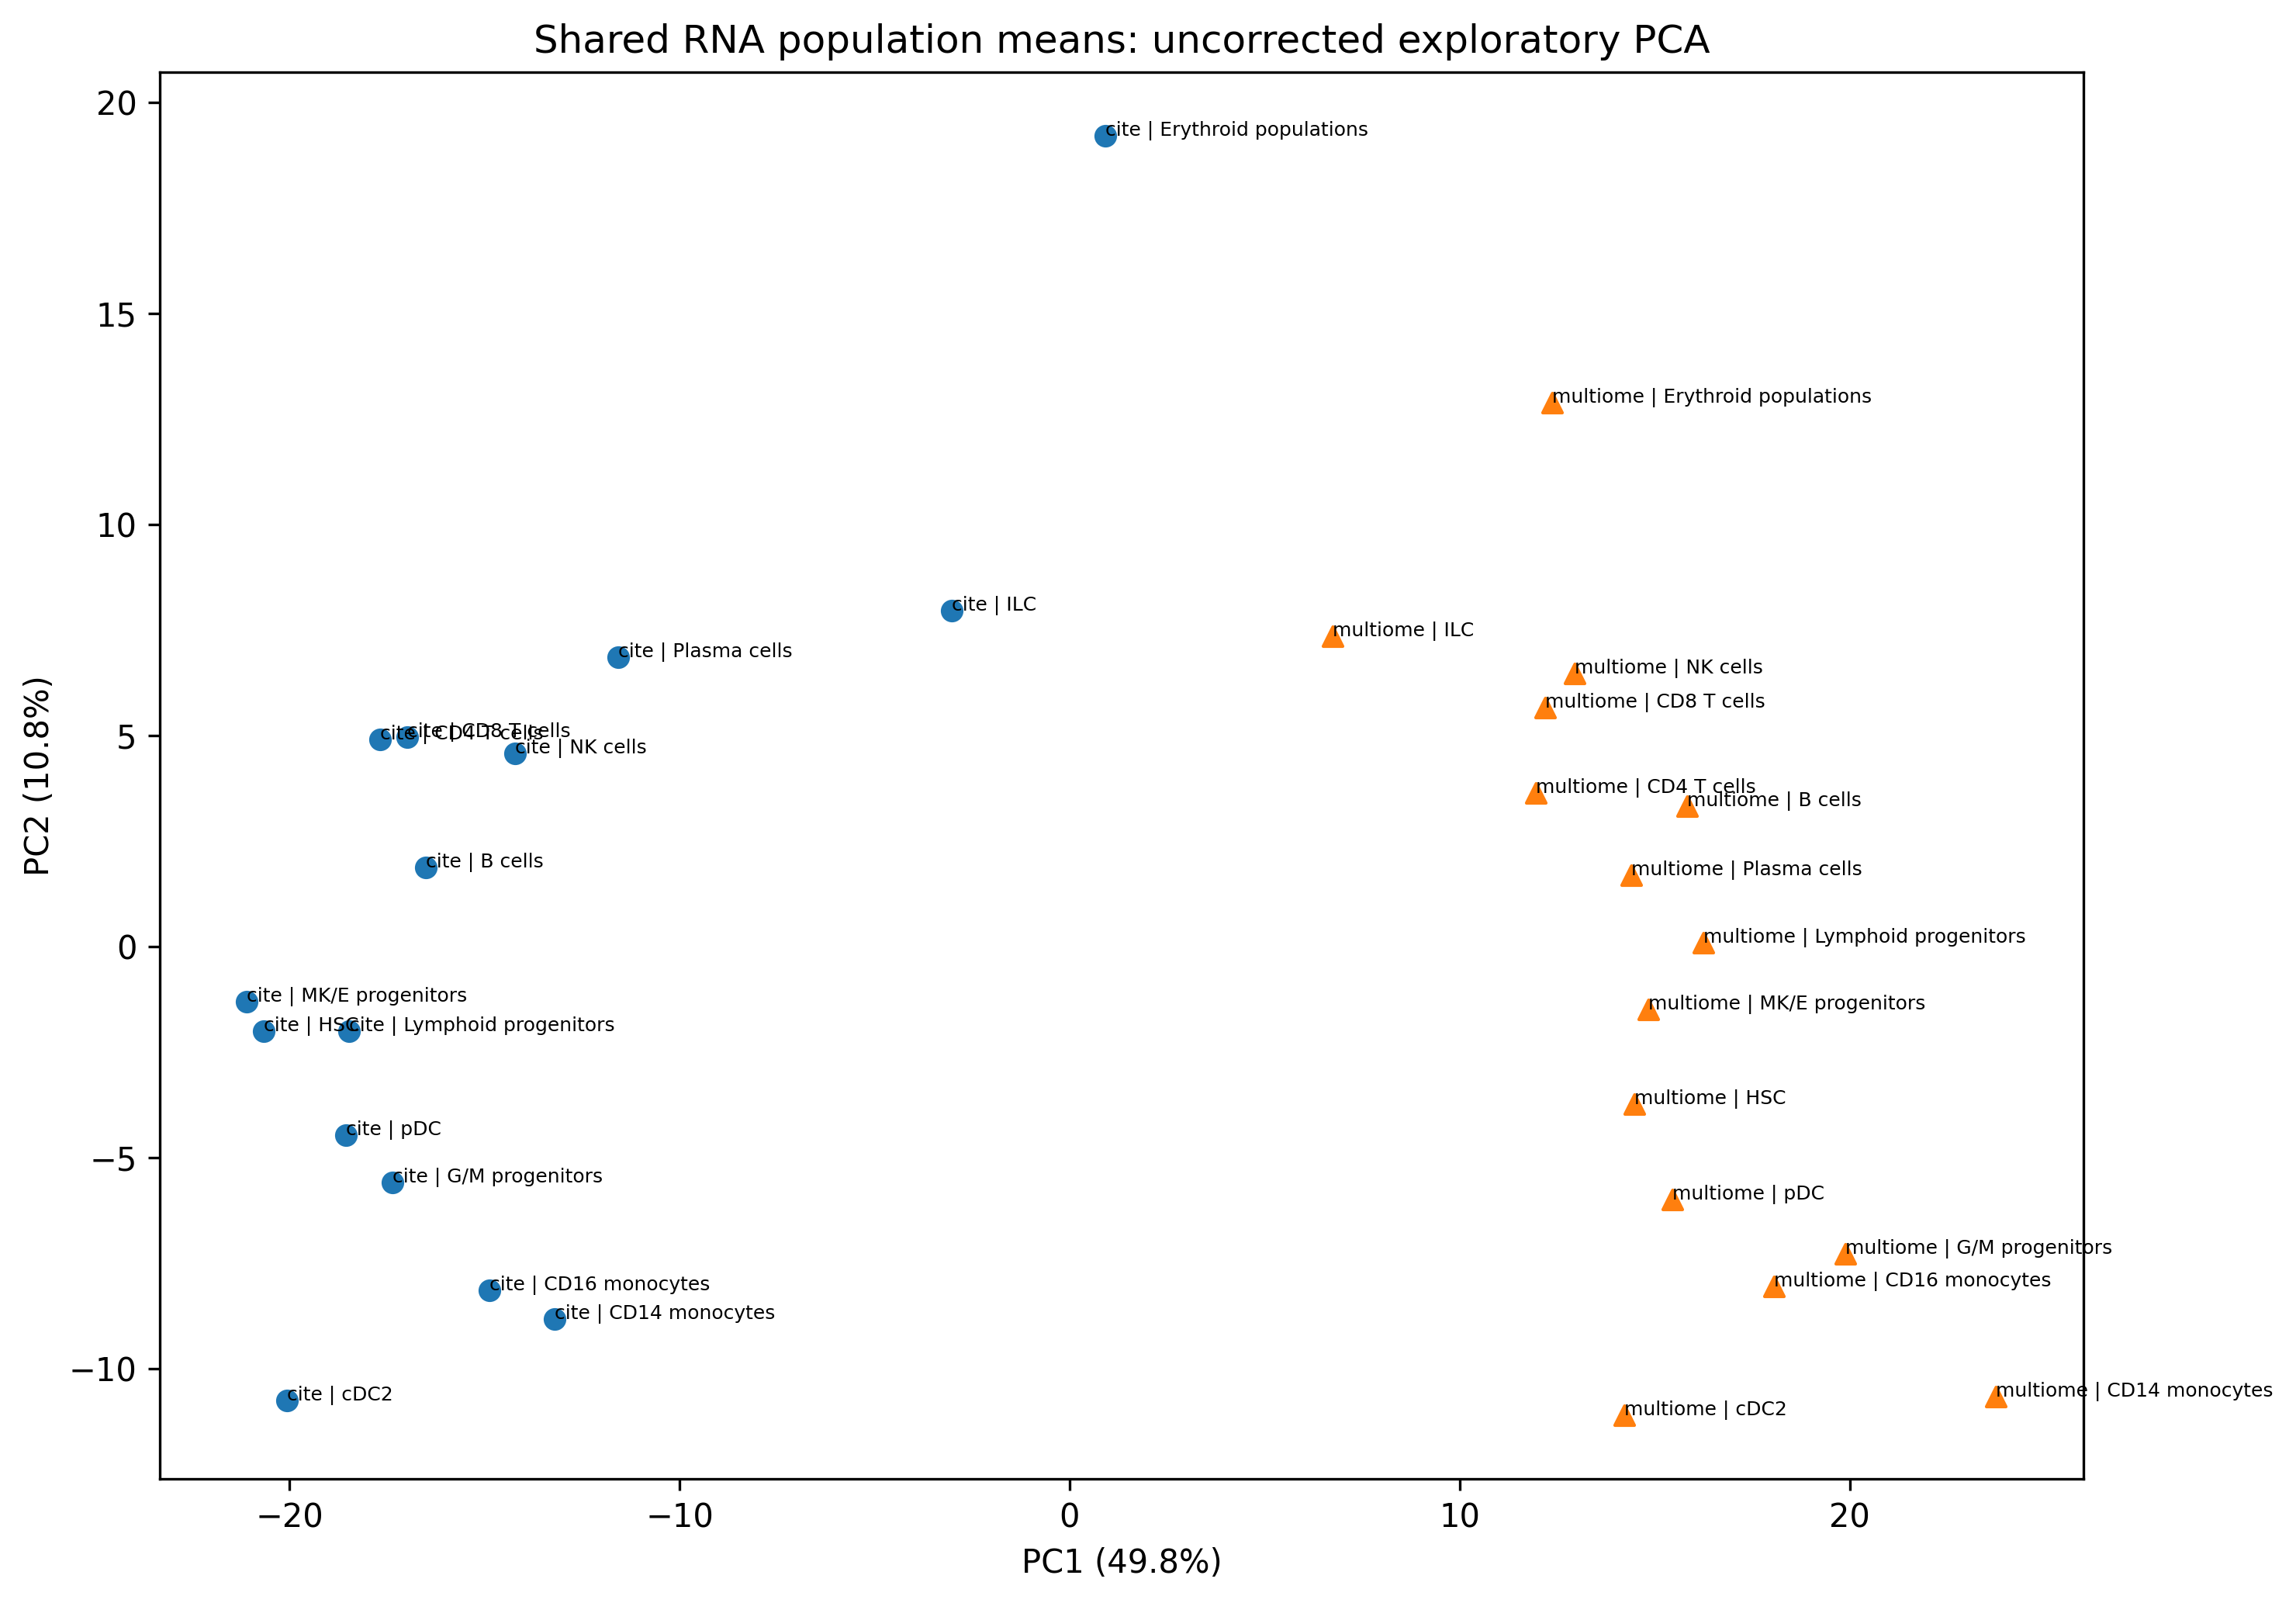

In [6]:
display(pd.read_csv(DIRS['rna_concordance'] / 'shared_centroid_pca.csv'))
display(Image(filename=str(DIRS['rna_concordance'] / 'figures/shared_centroid_pca.png')))

## Main findings
The quantitative report below is computed from this run. Use correlations, rank
overlap, pathway coverage, balanced draws, site checks and leading edges jointly to
assess the RNA bridge. No universal pass threshold or biological conclusion is
pre-filled. **Review these results before implementing ATAC and protein analyses.**

In [7]:
display(findings)
print('Saved tables, figures and provenance:', OUTPUT_ROOT)

{'donor': '15078',
 'n_shared_types': 15,
 'median_expression_pearson': 0.6279918787491388,
 'median_specificity_spearman': 0.6285686017678375,
 'pathway_classes': {'unsupported': 505,
  'CITE-specific': 97,
  'Multiome-specific': 61,
  'concordant active': 36,
  'concordant negative': 28,
  'not tested in both': 7,
  'discordant': 1},
 'n_followup_candidates': 10,
 'balanced_repeats': 5,
 'balanced_cap': 1000,
 'interpretation': 'Descriptive within-donor concordance; biological review required. No matched cross-capture cells.',
 'next_gate': 'Inspect mapping, site sensitivity, pathway coverage, effect sizes and leading edges before ATAC.'}

Saved tables, figures and provenance: /content/drive/MyDrive/multiomics-relationship-modeling/results/single_donor


In [8]:
selected = followup.loc[followup.selected_for_followup].copy()
display(selected[
    ["cell_type", "pathway", "NES_cite", "NES_multiome",
     "q_value_cite", "q_value_multiome",
     "shared_leading_edge", "balanced_direction_supported"]
])

,cell_type,pathway,NES_cite,NES_multiome,q_value_cite,q_value_multiome,shared_leading_edge,balanced_direction_supported
72,CD14 monocytes,Inflammatory Response,1.886618,1.868768,0.010355,0.012084,AHR;AQP9;ATP2B1;C5AR1;CD14;CD55;CSF3R;CXCL8;CY...,True
89,CD14 monocytes,TNF-alpha Signaling via NF-kB,2.042902,1.954407,0.010355,0.012084,ATF3;ATP2B1;B4GALT5;BCL2A1;BCL6;CCNL1;CD44;CD8...,True
107,CD16 monocytes,Coagulation,1.946928,1.978472,0.008788,0.009088,ANXA1;CFD;CTSB;DUSP6;LRP1;LTA4H;PECAM1;PLEK;SE...,True
122,CD16 monocytes,Interferon Alpha Response,1.947899,1.954336,0.008788,0.009088,B2M;BST2;CASP1;CD74;EPSTI1;GBP2;GBP4;HLA-C;IFI...,True
311,G/M progenitors,G2-M Checkpoint,1.672945,1.442670,0.021875,0.014333,ABL1;BARD1;BRCA2;CDC7;CDK4;CHAF1A;CHEK1;CUL1;C...,True
323,G/M progenitors,Myc Targets V1,2.080088,1.497309,0.017870,0.014333,ABCE1;APEX1;CANX;CBX3;CCT4;CCT7;COX5A;CUL1;DDX...,True
453,Lymphoid progenitors,E2F Targets,1.803852,1.909167,0.009829,0.012861,ANP32E;ASF1B;ATAD2;AURKB;BARD1;BIRC5;CBX5;CCNB...,True
458,Lymphoid progenitors,G2-M Checkpoint,1.777787,1.736588,0.009829,0.014416,ATRX;AURKB;BARD1;BIRC5;BUB1;CCNB2;CDC20;CDK1;C...,True
519,MK/E progenitors,Myc Targets V1,2.065594,2.036687,0.008886,0.012462,ABCE1;APEX1;C1QBP;CANX;CBX3;CCT2;CCT3;CCT4;CCT...,True
666,cDC2,Myc Targets V1,1.510156,1.575947,0.014201,0.008325,AIMP2;APEX1;C1QBP;CANX;CCT2;CCT4;CCT7;CLNS1A;C...,True


## Limitations
- One donor cannot establish reproducibility across individuals or donor effects.
- Separate CITE/Multiome cells prohibit cross-capture cell-level association claims.
- Broad lineage agreement can conceal subtype composition and capture differences.
- Correlation can be driven by abundant/housekeeping genes: inspect specificity and
  pathway agreement alongside mean expression, and check the technical gene flags.
- Gene-set permutation p-values ignore gene correlation; q-values describe the
  chosen exploratory test family, not condition or individual-level inference.
- Balanced subsampling cannot correct unmeasured technical or site confounders.
- Negative specificity is not biological inactivity; missing evidence is not absence.
- Subsequent protein coverage is limited, and ATAC gene activity approximates
  regulatory accessibility. Neither snapshot establishes causality or temporal priming.
- nb06–nb08 are deliberately deferred until this RNA milestone runs and is reviewed
  on the real benchmark files in Drive, following the requested incremental sequence.